In [1]:
%run compute_snr.py

In [6]:
import matplotlib.pyplot as plt

In [2]:
crps_samples = bootstrap(score_SSCrat, seas5, era5.flatten(), 100, scoring_rule=scoringrules.crps_ensemble)

ERROR:2025-09-29 12:11:45,301:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/eviatar/miniconda3/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/eviatar/miniconda3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/eviatar/miniconda3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_UNKNOWN
100%|█████████████████████████████████████████| 100/100 [09:09<00:00,  5.49s/it]


In [60]:
crps_best = score_SSCrat(seas5, era5.flatten(), scoring_rule=scoringrules.crps_ensemble)

(np.float32(0.90194744), np.float32(0.88766))

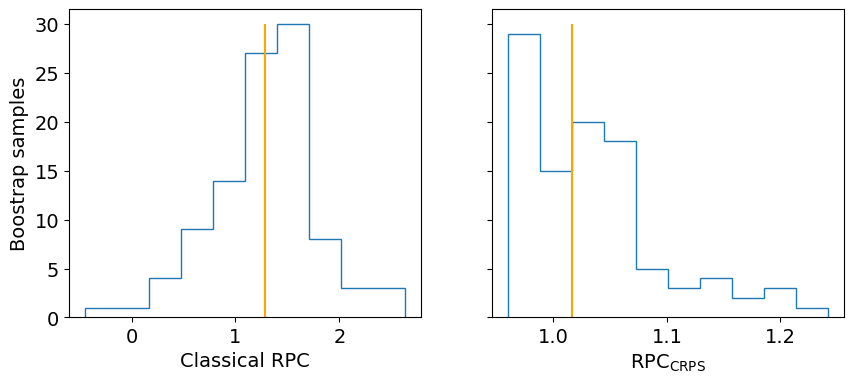

In [72]:
plt.rcParams.update({'font.size': 14})
fig, axs = plt.subplots(1, 2, figsize=(10,4), sharey=True)
#fig.suptitle('North Atlantic Oscillation')

axs[0].hist(rpc_samples, histtype='step')
axs[0].vlines([rpc_best], ymin=0, ymax=30, color="orange")
axs[0].set_xlabel(r"Classical RPC")
axs[0].set_ylabel("Boostrap samples")

axs[1].hist(crps_samples[:, 0]/crps_samples[:, 1], histtype='step')
axs[1].vlines([crps_best[0]/crps_best[1]], ymin=0, ymax=30, color="orange")
axs[1].set_xlabel(r"$\text{RPC}_\text{CRPS}$")

plt.savefig("nao_bootstrap.pdf")

In [74]:
np.quantile(crps_samples[:, 0]/crps_samples[:, 1], [0.025, 0.5, 0.975])

array([0.96507877, 1.0285219 , 1.19624494])

In [73]:
np.quantile(rpc_samples, [0.025, 0.5, 0.975])

array([0.35651346, 1.30574315, 2.30689635])

In [69]:
rpc_best = classic_RPC(seas5, era5.flatten())

In [70]:
rpc_best

np.float64(1.2869615325972277)

In [25]:
rpc_samples = bootstrap(classic_RPC, seas5, era5.flatten(), 100)

100%|███████████████████████████████████████| 100/100 [00:00<00:00, 4237.14it/s]


(array([ 1.,  1.,  4.,  9., 14., 27., 30.,  8.,  3.,  3.]),
 array([-0.44807491, -0.13980759,  0.16845973,  0.47672705,  0.78499437,
         1.09326169,  1.40152901,  1.70979633,  2.01806365,  2.32633097,
         2.63459829]),
 <BarContainer object of 10 artists>)

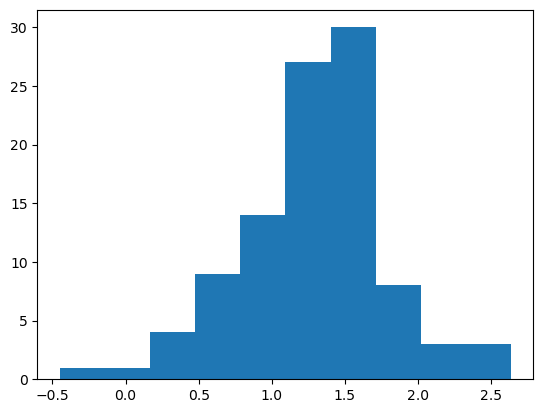

In [26]:
plt.hist(rpc_samples)

In [28]:
sum(rpc_samples > 1)

np.int64(78)

In [29]:
sum(crps_samples[:, 0]/crps_samples[:, 1] > 1)

np.int64(66)

In [75]:
crps_best[0]/crps_best[1]

np.float32(1.0160956)

In [76]:
np.save("nao_crps_samples.npy", crps_samples)